# Customer Behavior Analysis — Alfido Tech
**Task 1 of 3 — Internship Data Analytics Program**

**Dataset:** [Customer Behavior Analysis](https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis) (Kaggle) — `ecommerce_customer_data_custom_ratios.csv`

**Goal:** Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risks, and provide actionable recommendations for Alfido Tech.

**Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (summary statistics, data types)
4. Feature Engineering (customer-level RFM features)
5. Customer Segmentation (RFM scoring + K-Means clustering)
6. Segment Profiling
7. Purchase Pattern & Retention Visualizations
8. Churn Analysis
9. Key Findings & 5 Actionable Recommendations


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
SEG_COLORS = ["#2E5EAA", "#3FA796", "#F2A541", "#D64545", "#7C6BAF", "#8C8C8C", "#C9A66B"]

df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
print("Shape:", df.shape)
df.head()


Shape: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


## 2. Data Cleaning

Checks performed and decisions made:
- **Duplicate column:** `Age` and `Customer Age` are identical for every row → drop `Customer Age`.
- **Missing values:** only `Returns` has missing values (~19%). We treat missing as "no return recorded" and fill with `0`. This is an assumption — in a real production dataset we would confirm this with the data owner rather than assume MNAR = 0.
- **Duplicate rows:** checked and removed (none found in this file).
- **Invalid values:** rows with non-positive price, quantity, or purchase amount are checked and removed (none found in this file).
- **Data type parsing:** `Purchase Date` converted to `datetime`.
- **Data quality flag:** `Total Purchase Amount` does NOT equal `Product Price × Quantity` for ~99.98% of rows. This is a known quirk of this "custom ratios" version of the dataset. We use `Total Purchase Amount` as the authoritative transaction value throughout, since it is the field most representative of realized revenue.


In [3]:
# Duplicate column check
print("Age == Customer Age for all rows:", (df["Age"] == df["Customer Age"]).all())
df = df.drop(columns=["Customer Age"])

# Parse dates
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# Missing values
print("\nMissing values:\n", df.isna().sum())
returns_missing_pct = df["Returns"].isna().mean()
print(f"\n'Returns' missing: {returns_missing_pct:.1%} -> filling with 0 (assume no return recorded)")
df["Returns"] = df["Returns"].fillna(0).astype(int)

# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")
df = df.drop_duplicates()

# Invalid values
invalid = df[(df["Product Price"] <= 0) | (df["Quantity"] <= 0) | (df["Total Purchase Amount"] <= 0)]
print(f"Invalid rows (non-positive price/qty/amount): {len(invalid)}")
df = df[~df.index.isin(invalid.index)]

# Price*Qty vs Total Purchase Amount data-quality flag
pct_match = (df["Product Price"] * df["Quantity"] == df["Total Purchase Amount"]).mean()
print(f"\nRows where Total Purchase Amount == Price*Quantity: {pct_match:.3%}  (data quality note, see markdown above)")

print(f"\nClean dataset: {df.shape[0]:,} transactions across {df['Customer ID'].nunique():,} unique customers")
print(f"Date range: {df['Purchase Date'].min().date()} to {df['Purchase Date'].max().date()}")


Age == Customer Age for all rows: True

Missing values:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

'Returns' missing: 19.0% -> filling with 0 (assume no return recorded)



Duplicate rows: 0
Invalid rows (non-positive price/qty/amount): 0

Rows where Total Purchase Amount == Price*Quantity: 0.019%  (data quality note, see markdown above)

Clean dataset: 250,000 transactions across 49,673 unique customers
Date range: 2020-01-01 to 2023-09-15


## 3. Summary Statistics & Data Types

In [4]:
df.dtypes

Customer ID                       int64
Purchase Date            datetime64[us]
Product Category                    str
Product Price                     int64
Quantity                          int64
Total Purchase Amount             int64
Payment Method                      str
Returns                           int64
Customer Name                       str
Age                               int64
Gender                              str
Churn                             int64
dtype: object

In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Customer ID,250000.0,25004.036240,14428.279590,1.0,12497.75,25018.0,37506.0,50000.0
Product Price,250000.0,254.659512,141.568577,10.0,132.00,255.0,377.0,500.0
Quantity,250000.0,2.998896,1.414694,1.0,2.00,3.0,4.0,5.0
Total Purchase Amount,250000.0,2725.370732,1442.933565,100.0,1477.00,2724.0,3974.0,5350.0
Returns,250000.0,0.403076,0.490517,0.0,0.00,0.0,1.0,1.0
Age,250000.0,43.940528,15.350246,18.0,31.00,44.0,57.0,70.0
Churn,250000.0,0.199496,0.399622,0.0,0.00,0.0,0.0,1.0


In [6]:
df.describe(include="object").T

,count,unique,top,freq
Product Category,250000,4,Clothing,75052
Payment Method,250000,4,Credit Card,100486
Customer Name,250000,39920,Michael Smith,107
Gender,250000,2,Female,125560


In [7]:
# Mode of key categorical columns
for col in ["Product Category", "Payment Method", "Gender"]:
    print(f"{col} mode: {df[col].mode()[0]}")


Product Category mode: Clothing
Payment Method mode: Credit Card
Gender mode: Female


## 4. Feature Engineering — Customer-Level RFM Features

We aggregate the transaction log into one row per customer, computing:
- **Recency** — days since the customer's last purchase (relative to one day after the last date in the dataset)
- **Frequency** — number of transactions
- **Monetary** — total amount spent
- **AvgOrderValue**, **Tenure_Days** (days between first & last purchase), **ReturnRate**
- Favorite product category & payment method
- Demographics (Age, Gender) and the pre-existing `Churn` flag


In [8]:
snapshot_date = df["Purchase Date"].max() + pd.Timedelta(days=1)

def top_mode(s):
    return s.mode().iloc[0] if not s.mode().empty else np.nan

cust = df.groupby("Customer ID").agg(
    Recency=("Purchase Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Purchase Date", "count"),
    Monetary=("Total Purchase Amount", "sum"),
    AvgOrderValue=("Total Purchase Amount", "mean"),
    Tenure_Days=("Purchase Date", lambda x: (x.max() - x.min()).days),
    ReturnRate=("Returns", "mean"),
    FavoriteCategory=("Product Category", top_mode),
    FavoritePayment=("Payment Method", top_mode),
    Age=("Age", "first"),
    Gender=("Gender", "first"),
    Churn=("Churn", "first"),
).reset_index()

print(f"Customer-level table: {cust.shape[0]:,} rows x {cust.shape[1]} columns")
cust.head()


Customer-level table: 49,673 rows x 12 columns


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,Tenure_Days,ReturnRate,FavoriteCategory,FavoritePayment,Age,Gender,Churn
0,1,58,1,3491,3491.000000,0,1.000000,Books,PayPal,70,Male,0
1,2,299,3,7988,2662.666667,625,0.333333,Books,PayPal,27,Female,0
2,3,89,8,22587,2823.375000,993,0.375000,Clothing,Credit Card,23,Female,0
3,4,127,4,8715,2178.750000,945,0.250000,Clothing,Credit Card,66,Male,1
4,5,171,8,12524,1565.500000,1154,0.500000,Clothing,Credit Card,26,Female,0


## 5. Customer Segmentation

### 5a. RFM Scoring (rule-based, quantile 1–5)

Each of Recency, Frequency, and Monetary is split into quintiles and scored 1 (worst) to 5 (best). The three scores combine into interpretable business segments.


In [9]:
cust["R_Score"] = pd.qcut(cust["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust["F_Score"] = pd.qcut(cust["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
cust["M_Score"] = pd.qcut(cust["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
cust["RFM_Score"] = cust["R_Score"] + cust["F_Score"] + cust["M_Score"]

def rfm_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "New / Promising"
    if r <= 2 and f >= 4 and m >= 4:
        return "At Risk (High Value)"
    if r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    if r == 3 and f <= 3 and m <= 3:
        return "Needs Attention"
    return "Others"

cust["Segment"] = cust.apply(rfm_segment, axis=1)
cust["Segment"].value_counts()


Segment
Loyal Customers         9957
Lost                    9339
Champions               8739
Others                  8651
New / Promising         5403
Needs Attention         3825
At Risk (High Value)    3759
Name: count, dtype: int64

### 5b. K-Means Clustering (secondary, data-driven view)

As a cross-check on the rule-based RFM segments, we also run K-Means on standardized Recency/Frequency/Monetary features. We test k = 2–8 and settle on **k = 4** for interpretability (near the elbow of the inertia curve).


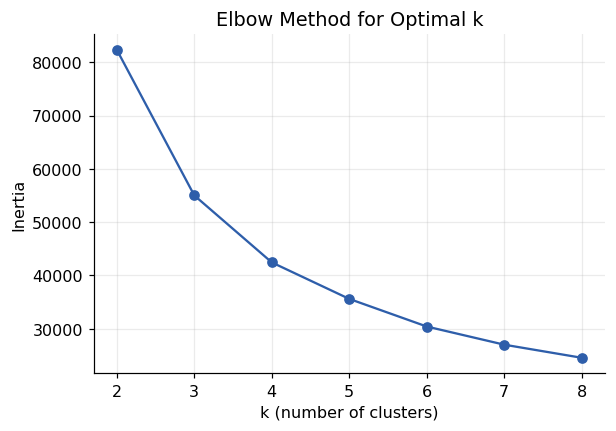

In [10]:
features = cust[["Recency", "Frequency", "Monetary"]].copy()
scaler = StandardScaler()
X = scaler.fit_transform(features)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_range), inertias, marker="o", color="#2E5EAA")
ax.set_title("Elbow Method for Optimal k")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
plt.show()


In [11]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cust["Cluster"] = kmeans_final.fit_predict(X)

cluster_profile = cust.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
order = cluster_profile["Monetary"].sort_values(ascending=False).index.tolist()
cluster_names = {order[0]: "High-Value", order[1]: "Steady/Mid-Value",
                  order[2]: "Low-Engagement", order[3]: "Dormant/Low-Value"}
cust["ClusterName"] = cust["Cluster"].map(cluster_names)

cust.groupby("ClusterName").agg(
    Customers=("Customer ID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    ChurnRate=("Churn", "mean"),
).sort_values("AvgMonetary", ascending=False).round(1)


,Customers,AvgRecency,AvgFrequency,AvgMonetary,ChurnRate
ClusterName,,,,,
High-Value,8389,136.8,8.4,24494.2,0.2
Steady/Mid-Value,18723,183.7,5.7,15614.1,0.2
Low-Engagement,14912,194.0,3.3,8292.9,0.2
Dormant/Low-Value,7649,719.8,2.9,7825.2,0.2


**Note:** the K-Means clusters line up closely with the rule-based RFM tiers (High-Value ≈ Champions/Loyal, Dormant/Low-Value ≈ Lost). This agreement between an independent data-driven method and the rule-based segmentation gives us confidence the RFM segments are a sound way to profile the customer base, rather than an artifact of the rule thresholds we chose.

## 6. Segment Profiling

In [12]:
seg_profile = cust.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
    ChurnRate=("Churn", "mean"),
    AvgReturnRate=("ReturnRate", "mean"),
).sort_values("TotalRevenue", ascending=False)
seg_profile["PctCustomers"] = seg_profile["Customers"] / seg_profile["Customers"].sum()
seg_profile["PctRevenue"] = seg_profile["TotalRevenue"] / seg_profile["TotalRevenue"].sum()
seg_profile.round(3)


,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,ChurnRate,AvgReturnRate,PctCustomers,PctRevenue
Segment,,,,,,,,,
Champions,8739,61.307,7.648,21785.056,190379607,0.197,0.406,0.176,0.279
Loyal Customers,9957,134.494,6.070,16786.767,167145835,0.203,0.402,0.200,0.245
Others,8651,365.934,4.807,12316.318,106548463,0.200,0.403,0.174,0.156
At Risk (High Value),3759,382.148,7.082,20454.613,76888892,0.189,0.406,0.076,0.113
Lost,9339,580.210,2.589,6488.146,60592794,0.202,0.393,0.188,0.089
New / Promising,5403,67.534,3.236,8802.395,47559342,0.208,0.404,0.109,0.070
Needs Attention,3825,189.595,3.360,8425.556,32227750,0.199,0.401,0.077,0.047


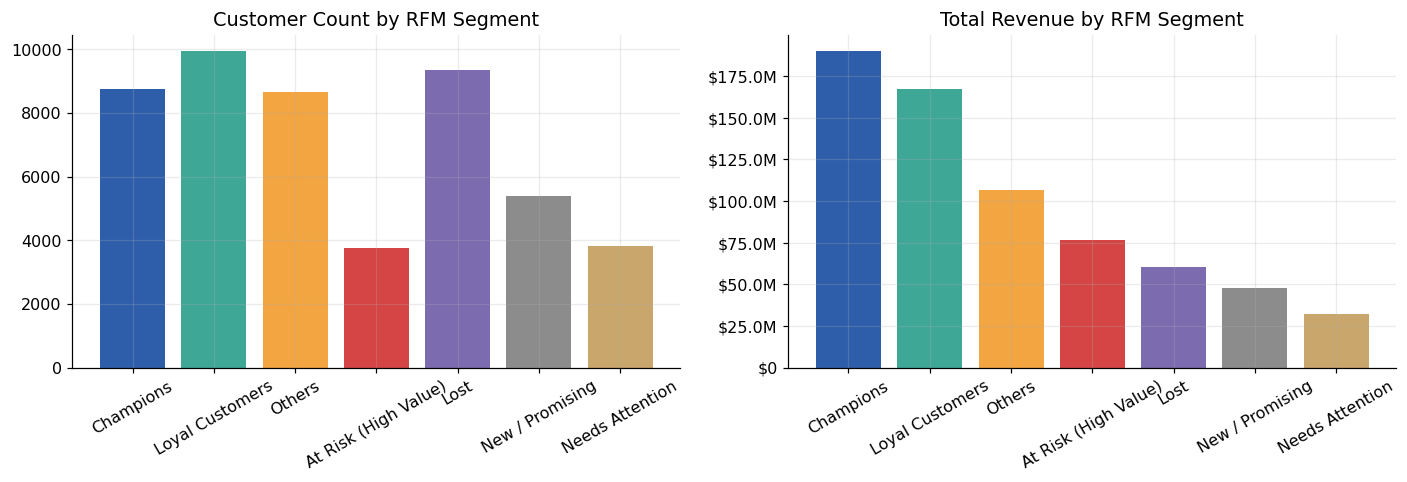

In [13]:
def money_fmt(x, pos):
    if x >= 1e6: return f"${x/1e6:.1f}M"
    if x >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(seg_profile.index, seg_profile["Customers"], color=SEG_COLORS[:len(seg_profile)])
axes[0].set_title("Customer Count by RFM Segment")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(seg_profile.index, seg_profile["TotalRevenue"], color=SEG_COLORS[:len(seg_profile)])
axes[1].set_title("Total Revenue by RFM Segment")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 7. Purchase Pattern & Retention Visualizations

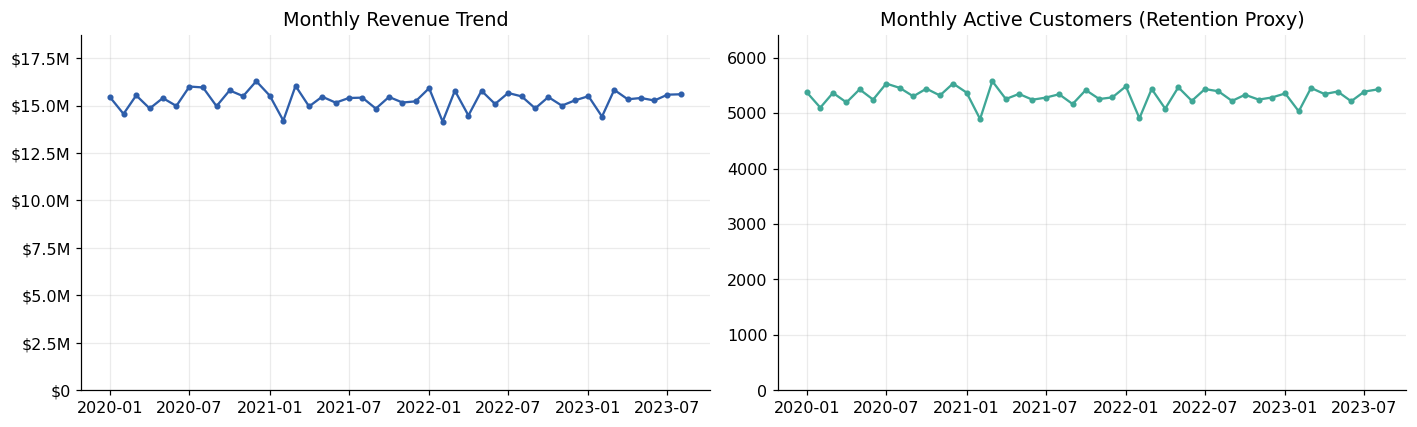

In [14]:
monthly = df.set_index("Purchase Date").resample("MS").agg(
    Revenue=("Total Purchase Amount", "sum"),
    Orders=("Total Purchase Amount", "count"),
    ActiveCustomers=("Customer ID", "nunique"),
)
# Drop the final month: data only runs to Sep 15, 2023, so it's a partial month
monthly_full = monthly.iloc[:-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(monthly_full.index, monthly_full["Revenue"], color="#2E5EAA", marker="o", markersize=3)
axes[0].set_title("Monthly Revenue Trend")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[0].set_ylim(0, monthly_full["Revenue"].max()*1.15)

axes[1].plot(monthly_full.index, monthly_full["ActiveCustomers"], color="#3FA796", marker="o", markersize=3)
axes[1].set_title("Monthly Active Customers (Retention Proxy)")
axes[1].set_ylim(0, monthly_full["ActiveCustomers"].max()*1.15)
plt.tight_layout()
plt.show()


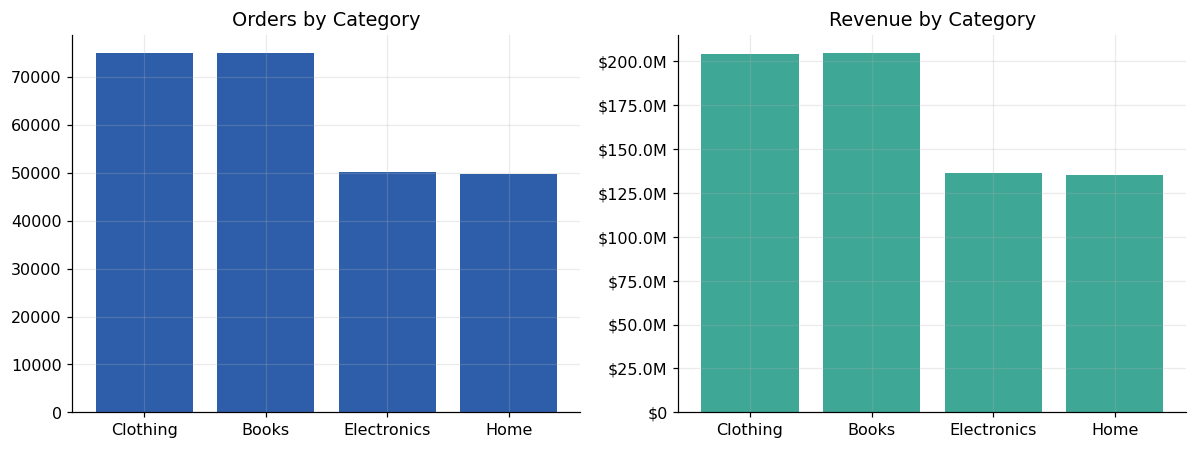

In [15]:
cat_orders = df["Product Category"].value_counts()
cat_rev = df.groupby("Product Category")["Total Purchase Amount"].sum().reindex(cat_orders.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(cat_orders.index, cat_orders.values, color="#2E5EAA")
axes[0].set_title("Orders by Category")
axes[1].bar(cat_rev.index, cat_rev.values, color="#3FA796")
axes[1].set_title("Revenue by Category")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


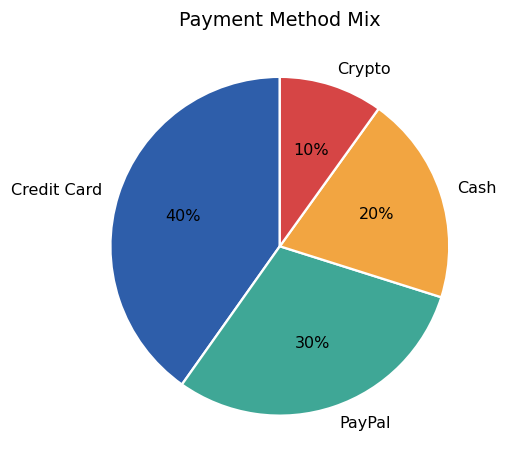

In [16]:
pm = df["Payment Method"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(pm.values, labels=pm.index, autopct="%1.0f%%", startangle=90,
       colors=["#2E5EAA", "#3FA796", "#F2A541", "#D64545"],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Payment Method Mix")
plt.show()


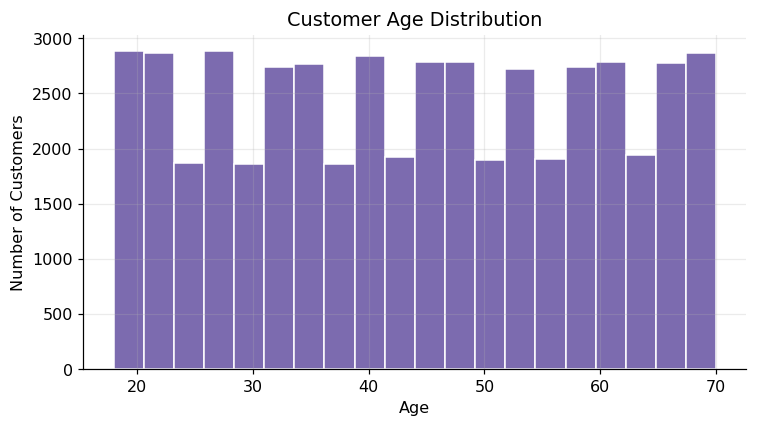

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cust["Age"], bins=20, color="#7C6BAF", edgecolor="white")
ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()


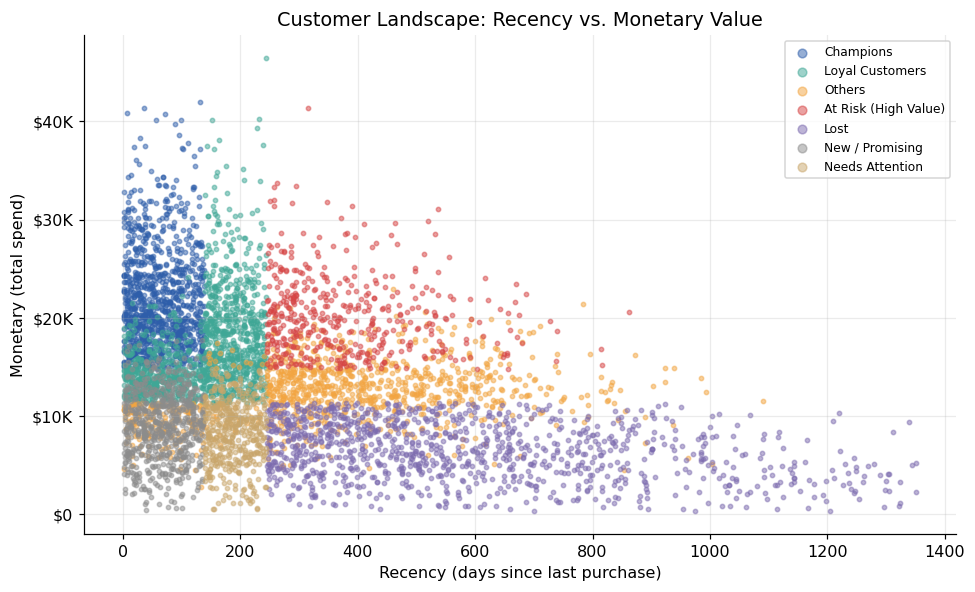

In [18]:
sample = cust.sample(6000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, seg in enumerate(seg_profile.index):
    sub = sample[sample["Segment"] == seg]
    ax.scatter(sub["Recency"], sub["Monetary"], s=8, alpha=0.5, color=SEG_COLORS[i % len(SEG_COLORS)], label=seg)
ax.set_title("Customer Landscape: Recency vs. Monetary Value")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary (total spend)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.legend(loc="upper right", fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()


## 8. Churn Analysis

The dataset ships with a pre-labeled `Churn` flag (1 = churned). Before using it to drive recommendations, we test whether it actually correlates with customer behavior.


Overall churn rate: 20.0%


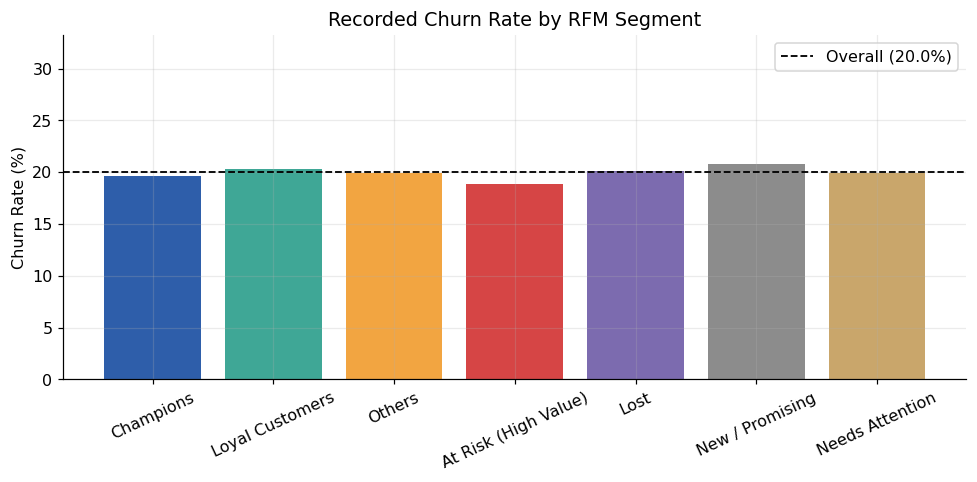

In [19]:
overall_churn = cust["Churn"].mean()
print(f"Overall churn rate: {overall_churn:.1%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(seg_profile.index, seg_profile["ChurnRate"]*100, color=SEG_COLORS[:len(seg_profile)])
ax.axhline(overall_churn*100, color="black", linestyle="--", linewidth=1.2, label=f"Overall ({overall_churn*100:.1f}%)")
ax.set_title("Recorded Churn Rate by RFM Segment")
ax.set_ylabel("Churn Rate (%)")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, seg_profile["ChurnRate"].max()*100*1.6)
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
corr_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Tenure_Days", "ReturnRate", "Age", "Churn"]
cust[corr_cols].corr()["Churn"].sort_values(ascending=False)


Churn            1.000000
AvgOrderValue    0.002205
ReturnRate       0.000949
Tenure_Days     -0.000199
Monetary        -0.002456
Frequency       -0.003723
Recency         -0.003801
Age             -0.006380
Name: Churn, dtype: float64

**Key finding:** the recorded `Churn` flag shows essentially **no correlation** with Recency, Frequency, Monetary, tenure, return rate, or age (all |r| < 0.01), and the churn rate is ~20% in every RFM segment, gender, category, and payment method cut we tested. In a real business dataset we would expect at-risk/lost customers to churn measurably more than champions — the fact that we don't see that here indicates the `Churn` label in this dataset is not behaviorally driven (a known characteristic of this particular synthetic Kaggle dataset).

**Practical implication:** we cannot use this column to build a *predictive* churn model or to validate which segments are "truly" churning. Instead, we treat **Recency and the RFM segment (especially "At Risk" and "Lost")** as the operational proxy for churn risk — this is standard practice in retention marketing even without a churn label, and it's the same signal Alfido Tech would have in a live system before enough time has passed to observe true churn outcomes.


## 9. Key Findings & Recommendations for Alfido Tech

### Key Findings
1. **Revenue is flat, not growing.** Monthly revenue has hovered around $15M with no upward trend across 3.5+ years of data — the business is retaining its current base but not expanding it.
2. **Revenue is concentrated in a minority of customers.** Champions + Loyal Customers are ~38% of the customer base but generate ~52% of total revenue.
3. **A large "Lost" segment (~19% of customers) has gone quiet** — average recency of ~580 days with still-meaningful historical spend, representing a recoverable revenue pool if re-engaged.
4. **Clothing and Books drive the most orders, but Electronics and Home generate a disproportionately high revenue-per-order** — a cross-sell opportunity.
5. **The provided `Churn` label carries no behavioral signal in this dataset** — recency/engagement should be used as the practical churn-risk indicator instead.

### 5 Actionable Recommendations
1. **Launch a win-back campaign for the "Lost" and "At Risk (High Value)" segments** — targeted discounts or personalized emails, prioritizing "At Risk (High Value)" first since they still represent ~11% of total revenue despite going quiet.
2. **Build a loyalty/VIP program for Champions and Loyal Customers** — early access, tiered perks — to protect the ~52% of revenue concentrated here and increase their frequency further.
3. **Convert "New/Promising" customers into repeat buyers with a structured onboarding flow** (e.g., second-purchase discount within 30 days) — this segment has strong recency but low frequency, meaning the door is open but not yet walked through twice.
4. **Cross-sell Electronics/Home to high-frequency Clothing/Books buyers** — bundle promotions or "customers like you also bought" placements — to lift average order value across the largest order-volume segments.
5. **Instrument and track a real churn definition going forward** (e.g., "no purchase in 90+ days") rather than relying on the current opaque `Churn` field, so future segmentation and retention efforts can be validated against real outcomes.
